# Uczenie ze wzmocnieniem

In [6]:
import gymnasium as gym
import time

env = gym.make("CartPole-v1", render_mode="human")
obs, info = env.reset()

start = time.time()
steps = 0
episodes = 0

step=100

while steps < step:
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    time.sleep(0.02)  # umożliwia płynne renderowanie na Windowsie
    steps += 1

    if done:
        obs, info = env.reset()
        episodes += 1

end = time.time()
print("FPS:", steps / (end - start))
print("Epizodów:", episodes)


FPS: 41.419992476999695
Epizodów: 3


## Implementacja Q-learningu na FrozenLake-v1

In [10]:
import numpy as np
import gymnasium as gym

env = gym.make("FrozenLake-v1", is_slippery=False)
n_states = env.observation_space.n
n_actions = env.action_space.n

Q = np.zeros((n_states, n_actions))

epsilon = 0.1
alpha = 0.1
gamma = 0.99
episodes = 1000

rewards = []

for episode in range(episodes):
    state, info = env.reset()
    done = False
    total_reward = 0
    while not done:
        if np.random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q[state])

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        Q[state, action] = Q[state, action] + alpha * (
            reward + gamma * np.max(Q[next_state]) - Q[state, action]
        )
        state = next_state
        total_reward += reward

    rewards.append(total_reward)

## Ewaluacja

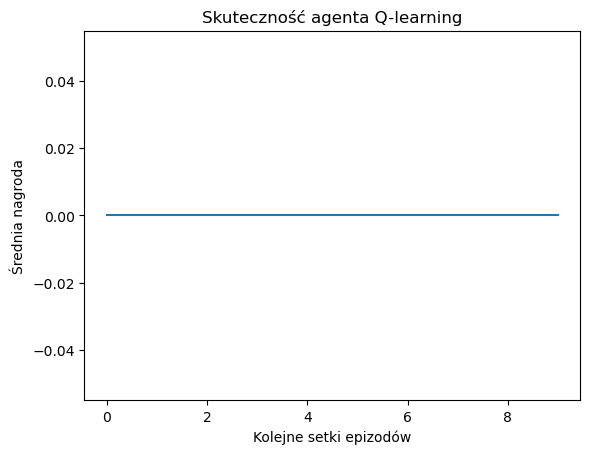

In [3]:
import matplotlib.pyplot as plt

avg_rewards = [np.mean(rewards[i:i+100]) for i in range(0, episodes, 100)]
plt.plot(avg_rewards)
plt.xlabel("Kolejne setki epizodów")
plt.ylabel("Średnia nagroda")
plt.title("Skuteczność agenta Q-learning")
plt.show()

## Frozen Lake - v1

In [11]:
import gymnasium as gym

env = gym.make("FrozenLake-v1", is_slippery=False)
state, info = env.reset()

done = False
while not done:
    print("Stan:", state)

    action = env.action_space.sample()  # losowa akcja (0=lewo, 1=dół, 2=prawo, 3=góra)
    next_state, reward, terminated, truncated, info = env.step(action)

    print(" -> akcja:", action)
    print(" -> nowy stan:", next_state)
    print(" -> nagroda:", reward)
    print(" -> koniec?", terminated or truncated)
    print("-" * 20)

    done = terminated or truncated
    state = next_state


Stan: 0
 -> akcja: 2
 -> nowy stan: 1
 -> nagroda: 0
 -> koniec? False
--------------------
Stan: 1
 -> akcja: 2
 -> nowy stan: 2
 -> nagroda: 0
 -> koniec? False
--------------------
Stan: 2
 -> akcja: 1
 -> nowy stan: 6
 -> nagroda: 0
 -> koniec? False
--------------------
Stan: 6
 -> akcja: 1
 -> nowy stan: 10
 -> nagroda: 0
 -> koniec? False
--------------------
Stan: 10
 -> akcja: 3
 -> nowy stan: 6
 -> nagroda: 0
 -> koniec? False
--------------------
Stan: 6
 -> akcja: 0
 -> nowy stan: 5
 -> nagroda: 0
 -> koniec? True
--------------------


## Taxi - v3

In [12]:
import gymnasium as gym

env = gym.make("Taxi-v3", render_mode="ansi")  # render tekstowy

state, info = env.reset()
done = False

while not done:
    print(env.render())  # pokaż planszę w terminalu

    action = env.action_space.sample()  # losowa akcja
    next_state, reward, terminated, truncated, info = env.step(action)

    print("Akcja:", action)
    print("Nagroda:", reward)
    print("-" * 20)

    done = terminated or truncated
    state = next_state


+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+


Akcja: 0
Nagroda: -1
--------------------
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (South)

Akcja: 4
Nagroda: -10
--------------------
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Pickup)

Akcja: 1
Nagroda: -1
--------------------
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (North)

Akcja: 5
Nagroda: -10
--------------------
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Dropoff)

Akcja: 0
Nagroda: -1
--------------------
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (South)

Akcja: 0
Nagroda: -1
--------------------
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (South)

Akcja: 4
Nagroda: -10
--------------------
+---------+
|R: | : :G|
| : | : : |
| : : : 

# CartPole - v1

In [14]:
import gymnasium as gym
import time

env = gym.make("CartPole-v1", render_mode="human")
obs, info = env.reset()

ranges=100

for _ in range(ranges):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    time.sleep(0.02)
    if done:
        obs, info = env.reset()

## Jak tworzyć własne środowisko?

In [4]:
import gymnasium as gym
from gymnasium import spaces
from gymnasium.envs.registration import register
import numpy as np

class MyEnv(gym.Env):
    def __init__(self):
        super().__init__()
        self.observation_space = spaces.Discrete(5)
        self.action_space = spaces.Discrete(2)
        self.state = 0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.state = 0
        return self.state, {}

    def step(self, action):
        self.state = (self.state + 1) % 5
        reward = 1 if self.state == 0 else 0
        terminated = self.state == 0
        truncated = False
        return self.state, reward, terminated, truncated, {}

    def render(self):
        print(f"Stan: {self.state}")


In [5]:
# Aby użyć środowiska, można je zarejestrować:

register(
    id="MyEnv-v0",
    entry_point=MyEnv   # lepiej niż "__main__:MyEnv"
)

env = gym.make("MyEnv-v0")

obs, info = env.reset()
print("Start:", obs)

# Ten kod tworzy proste środowisko, w którym agent przechodzi przez 5 stanów cyklicznie, a nagroda przyznawana jest tylko za powrót do stanu 0.


Start: 0
